# Data Preparation & Setup

## Market Fundamentals Data

In [1]:
import pandas as pd
import os
import warnings
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

warnings.filterwarnings('ignore')

tickers = ['NVDA', 'INTC', 'QCOM', 'AMD', 'MSFT', 'ADBE', 'INTU', 'AAPL', 'CSCO', 'AMAT']
master_data = []

print("Converting QuickFS Excel files to Master CSV...")

# UPGRADED SMART LOCATOR: Case-insensitive and ignores commas!
def get_row(df, possible_names, ticker, metric_name):
    clean_index = df.index.dropna().astype(str).str.lower().str.replace(',', '').str.strip()
    for name in possible_names:
        clean_name = name.lower().replace(',', '').strip()
        if clean_name in clean_index:
            original_row_name = df.index[clean_index == clean_name][0]
            return df.loc[original_row_name]
    raise ValueError(f"Could not find '{metric_name}' for {ticker}. Looked for: {possible_names}")

for ticker in tickers:
    filename = f"{ticker}_quarterly_all_descending.xlsx"

    if not os.path.exists(filename):
        print(f"Missing {filename}.")
        continue

    try:
        inc_stmt = pd.read_excel(filename, sheet_name='Income Statement', index_col=0)
        bal_sheet = pd.read_excel(filename, sheet_name='Balance Sheet', index_col=0)
        cash_flow = pd.read_excel(filename, sheet_name='Cash Flow', index_col=0)

        # Extract core financials from quarterly data
        revenue = get_row(inc_stmt, ['Revenue', 'Net Revenue', 'Total Revenue'], ticker, 'Revenue')
        net_income = get_row(inc_stmt, ['Net Income', 'Net Income (Continuing)'], ticker, 'Net Income')

        total_equity = get_row(bal_sheet, [
            "Shareholders' Equity", "Stockholders' Equity", "Total Equity",
            "Total Stockholders Equity", "Shareholders Equity"
        ], ticker, 'Total Equity')

        op_cf = get_row(cash_flow, ['Cash from Operations', 'Cash from Operating Activities'], ticker, 'Operating CF')
        capex = get_row(cash_flow, ['Property, Plant & Equipment', 'Capital Expenditures'], ticker, 'CapEx')

        # clean time-series dataset per company
        ticker_df = pd.DataFrame({
            'Revenue': revenue,
            'Net_Income': net_income,
            'Total_Equity': total_equity,
            'Operating_CF': op_cf,
            'CapEx': capex
        }).T.dropna(axis=1, how='all').T

        ticker_df['Ticker'] = ticker
        ticker_df.index.name = 'Date'
        ticker_df.reset_index(inplace=True)

        # Merge
        master_data.append(ticker_df)
        print(f"Successfully processed {ticker}")

    except Exception as e:
        print(f"Error processing {ticker}: {e}")

if master_data:
    final_df = pd.concat(master_data, ignore_index=True)

    # Clean dates (Removes the 'Q1 ' so Python can read 'Jan 2020')
    final_df['Date'] = final_df['Date'].astype(str).str.replace(r'Q[1-4]\s', '', regex=True)
    final_df['Date'] = pd.to_datetime(final_df['Date'], errors='coerce')
    final_df.dropna(subset=['Date'], inplace=True)

    # Sort chronologically
    final_df = final_df.sort_values(by=['Ticker', 'Date'])

    final_df.to_csv('Thesis_Fundamentals.csv', index=False)
    print("\n CSV 'Thesis_Fundamentals.csv' created.")

Converting QuickFS Excel files to Master CSV...
Successfully processed NVDA
Successfully processed INTC
Successfully processed QCOM
Successfully processed AMD
Successfully processed MSFT
Successfully processed ADBE
Successfully processed INTU
Successfully processed AAPL
Successfully processed CSCO
Successfully processed AMAT

 CSV 'Thesis_Fundamentals.csv' created.


## Market Data Download & Return Calculation

In [2]:
import yfinance as yf
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

print("Downloading Data Snapshot (2007-2026)...")
tickers = ['NVDA', 'INTC', 'QCOM', 'AMD', 'MSFT', 'ADBE', 'INTU', 'AAPL', 'CSCO', 'AMAT']
benchmarks = ['XLK', '^VIX']
start_date = '2007-01-01'
end_date = '2026-03-31'


data = yf.download(tickers + benchmarks, start=start_date, end=end_date)['Close']
data.to_csv("market_data_2007_2026.csv")

print("Market data saved to 'market_data_2007_2026.csv'. Your dataset is now locked.")

[*********************100%***********************]  12 of 12 completed

Market data saved to 'market_data_2007_2026.csv'. Your dataset is now locked.


# Explanatory Data Analysis (EDA)

In [3]:
print("Loading Data from CSV...")
tickers = ['NVDA', 'INTC', 'QCOM', 'AMD', 'MSFT', 'ADBE', 'INTU', 'AAPL', 'CSCO', 'AMAT']

if not os.path.exists("market_data_2007_2026.csv"):
    raise FileNotFoundError("'market_data_2007_2026.csv' not found. Run the Data Downloader script first!")

data = pd.read_csv("market_data_2007_2026.csv", index_col=0, parse_dates=True)

prices = data[tickers].ffill()
xlk, vix = data['XLK'].ffill(), data['^VIX'].ffill()

log_returns = np.log(prices / prices.shift(1)).dropna()
xlk_returns = np.log(xlk / xlk.shift(1)).dropna()

print("\nData loaded successfully. Generating EDA Visualizations & Statistical Tests...")

Loading Data from CSV...

Data loaded successfully. Generating EDA Visualizations & Statistical Tests...


## Descriptive Statistics & Normality Test


--- Descriptive Statistics & Normality Test ---
      Ann. Mean Return  Ann. Volatility  Skewness  Kurtosis
NVDA            0.2970           0.4914   -0.3252    9.1496
INTC            0.0635           0.3673   -0.4743   14.5988
QCOM            0.0872           0.3474   -0.0909    8.7753
AMD             0.1201           0.5801    0.2260    7.6442
MSFT            0.1476           0.2783   -0.0127    8.8009
ADBE            0.0937           0.3440   -0.5318    9.3328
INTU            0.1460           0.3078   -0.0403    7.6008
AAPL            0.2389           0.3134   -0.3043    6.9469
CSCO            0.0759           0.2829   -0.6417   12.3103
AMAT            0.1652           0.3878   -0.3486    4.9676

Jarque-Bera p-value: 0.0
Insight: The null hypothesis of normality is rejected (p < 0.05), confirming fat tails.


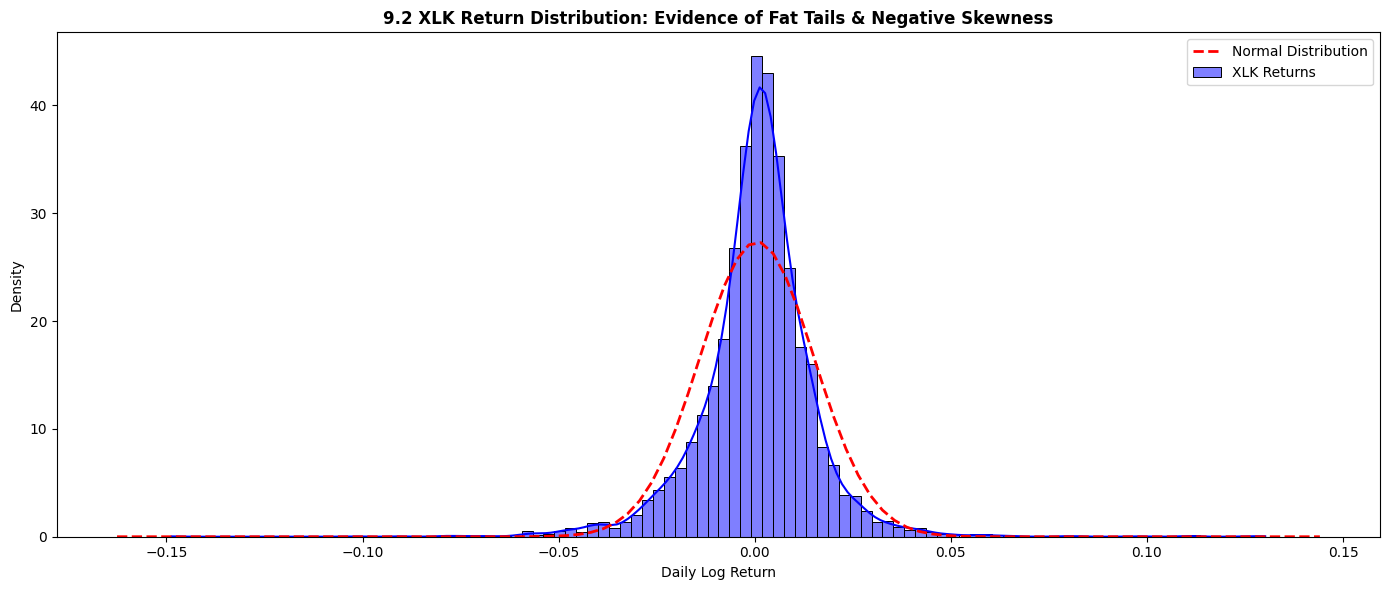

In [4]:
print("\n--- Descriptive Statistics & Normality Test ---")
desc_stats = pd.DataFrame({
    'Ann. Mean Return': log_returns.mean() * 252,
    'Ann. Volatility': log_returns.std() * np.sqrt(252),
    'Skewness': log_returns.apply(stats.skew),
    'Kurtosis': log_returns.apply(stats.kurtosis)
}).round(4)
print(desc_stats)

# Normality Test
jb_stat, jb_p = stats.jarque_bera(xlk_returns)
print(f"\nJarque-Bera p-value: {jb_p}")
if jb_p < 0.05:
    print("Insight: The null hypothesis of normality is rejected (p < 0.05), confirming fat tails.")

fig, ax = plt.subplots(figsize=(14, 6))
sns.histplot(xlk_returns, bins=100, kde=True, stat="density", color='blue', label='XLK Returns', ax=ax)
x0, x1 = ax.get_xlim()
x_pdf = np.linspace(x0, x1, 100)
y_pdf = stats.norm.pdf(x_pdf, loc=xlk_returns.mean(), scale=xlk_returns.std())
ax.plot(x_pdf, y_pdf, 'r--', lw=2, label='Normal Distribution')
ax.set_title('9.2 XLK Return Distribution: Evidence of Fat Tails & Negative Skewness', fontweight='bold')
ax.set_xlabel('Daily Log Return')
ax.legend()
plt.tight_layout()
plt.show()


## Volatility Clustering

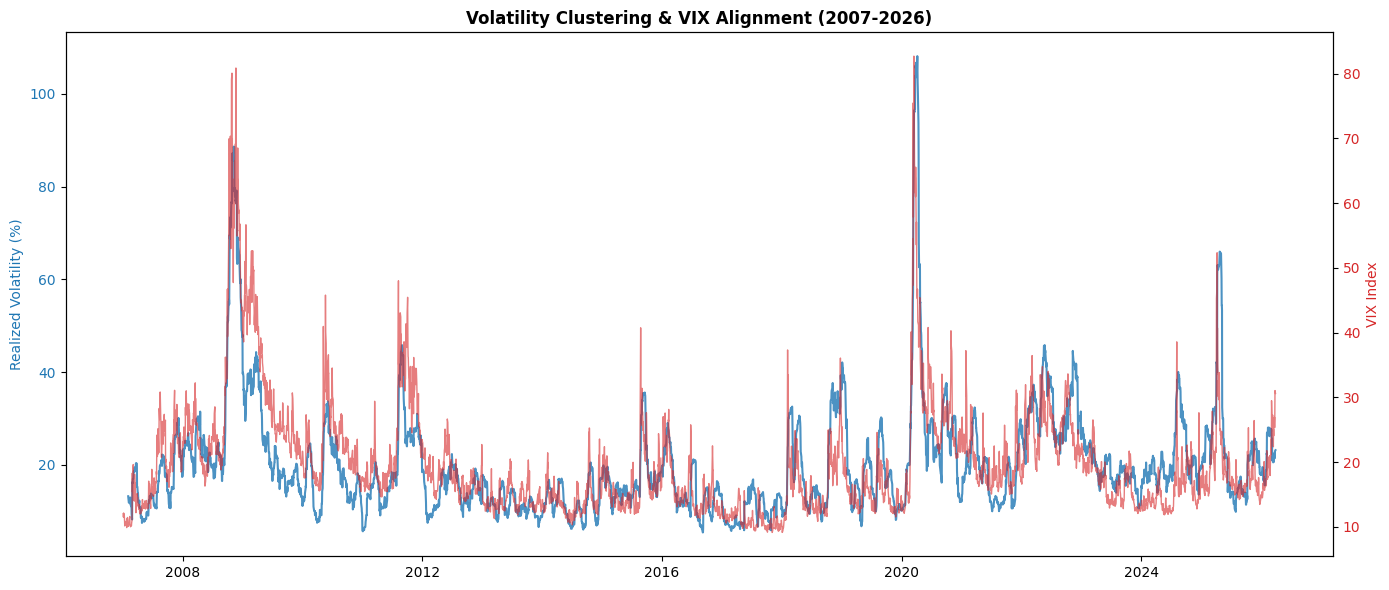

In [5]:
rolling_vol = xlk_returns.rolling(window=21).std() * np.sqrt(252) * 100

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(rolling_vol.index, rolling_vol, color='#1f77b4', label='XLK 21-Day Realized Volatility (%)', alpha=0.8)
ax1.set_ylabel('Realized Volatility (%)', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

ax2 = ax1.twinx()
ax2.plot(vix.index, vix, color='#d62728', label='VIX Index', alpha=0.6, linewidth=1)
ax2.set_ylabel('VIX Index', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')

plt.title('Volatility Clustering & VIX Alignment (2007-2026)', fontweight='bold')
fig.tight_layout()
plt.show()


## Correlation Analysis

### Relationship Between Stocks


--- Correlation Significance ---
NVDA vs AMD Pearson Correlation: 0.5414 | p-value: 0.00
Insight: The correlation is statistically significant (p < 0.05).


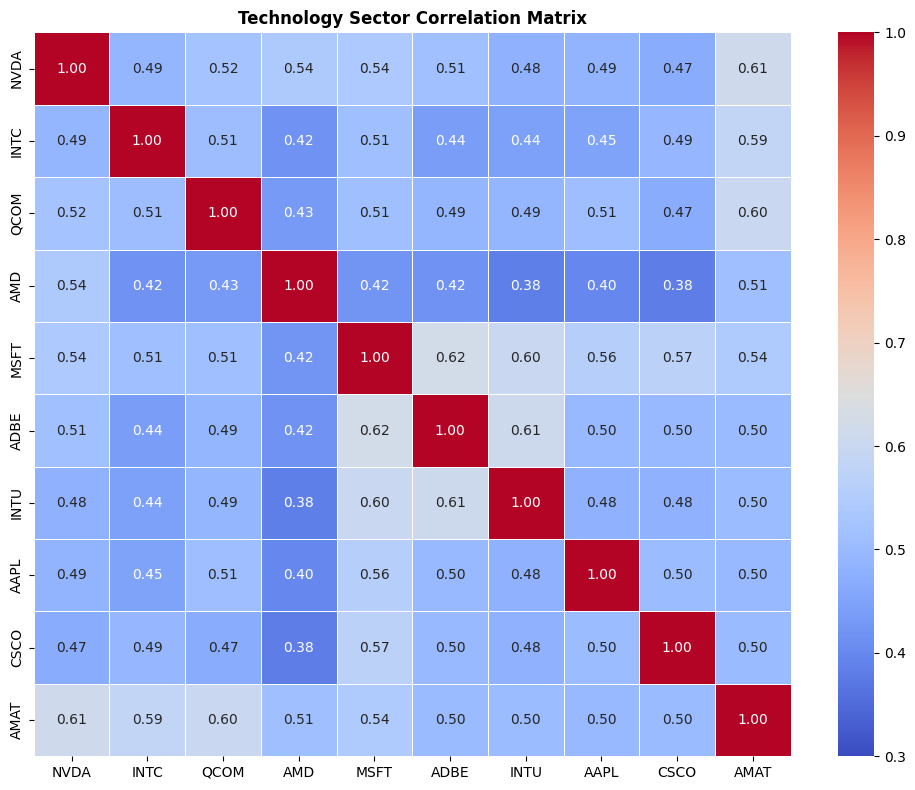

In [6]:
print("\n--- Correlation Significance ---")
corr, pval = stats.pearsonr(log_returns['NVDA'], log_returns['AMD'])
print(f"NVDA vs AMD Pearson Correlation: {corr:.4f} | p-value: {pval:.2f}")
if pval < 0.05:
    print("Insight: The correlation is statistically significant (p < 0.05).")

corr_matrix = log_returns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0.3, vmax=1.0, fmt=".2f", linewidths=.5)
plt.title('Technology Sector Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

### Asset correlations with XLK

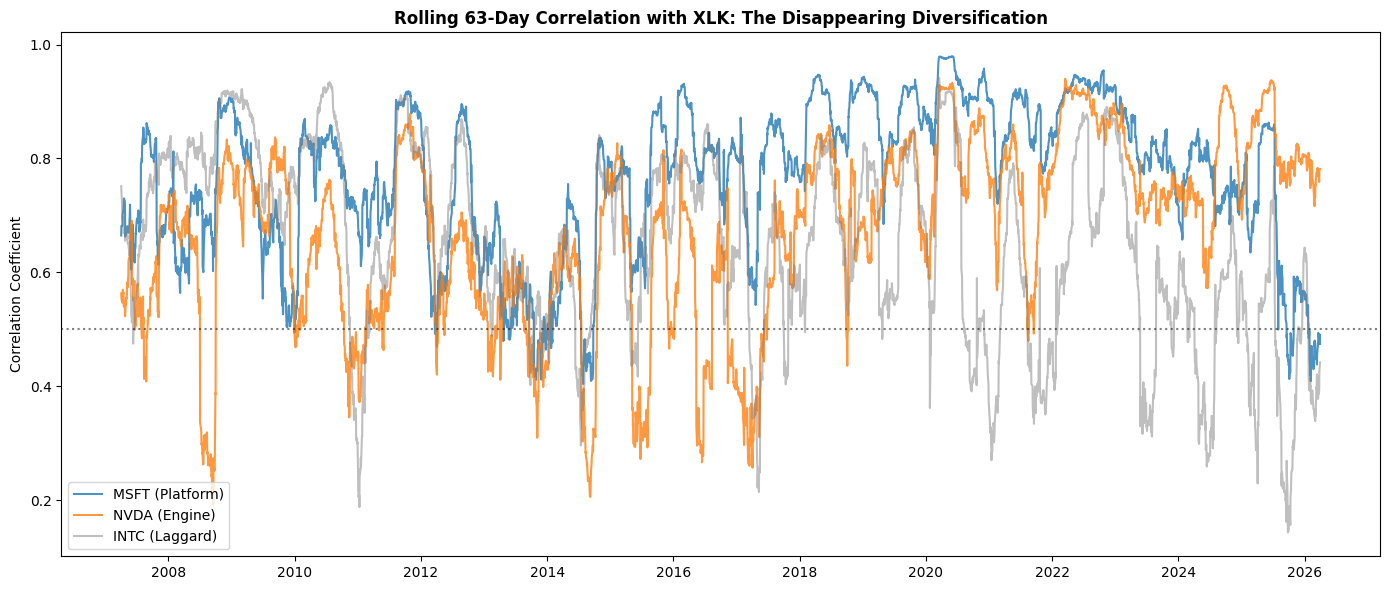

In [7]:
# Calculating correlation between DataFrame columns and a single Series returns a standard DataFrame.
rolling_corr = log_returns[['NVDA', 'MSFT', 'INTC']].rolling(window=63).corr(xlk_returns)

plt.figure(figsize=(14, 6))
# Plot columns directly to avoid MultiIndex .xs() crash
plt.plot(rolling_corr.index, rolling_corr['MSFT'], label='MSFT (Platform)', alpha=0.8)
plt.plot(rolling_corr.index, rolling_corr['NVDA'], label='NVDA (Engine)', alpha=0.8)
plt.plot(rolling_corr.index, rolling_corr['INTC'], label='INTC (Laggard)', alpha=0.5, color='gray')

plt.axhline(0.5, color='black', linestyle=':', alpha=0.5)
plt.title('Rolling 63-Day Correlation with XLK: The Disappearing Diversification', fontweight='bold')
plt.ylabel('Correlation Coefficient')
plt.legend()
plt.tight_layout()
plt.show()


## Conviction Factor

### Quality Factor Stability (ROE)

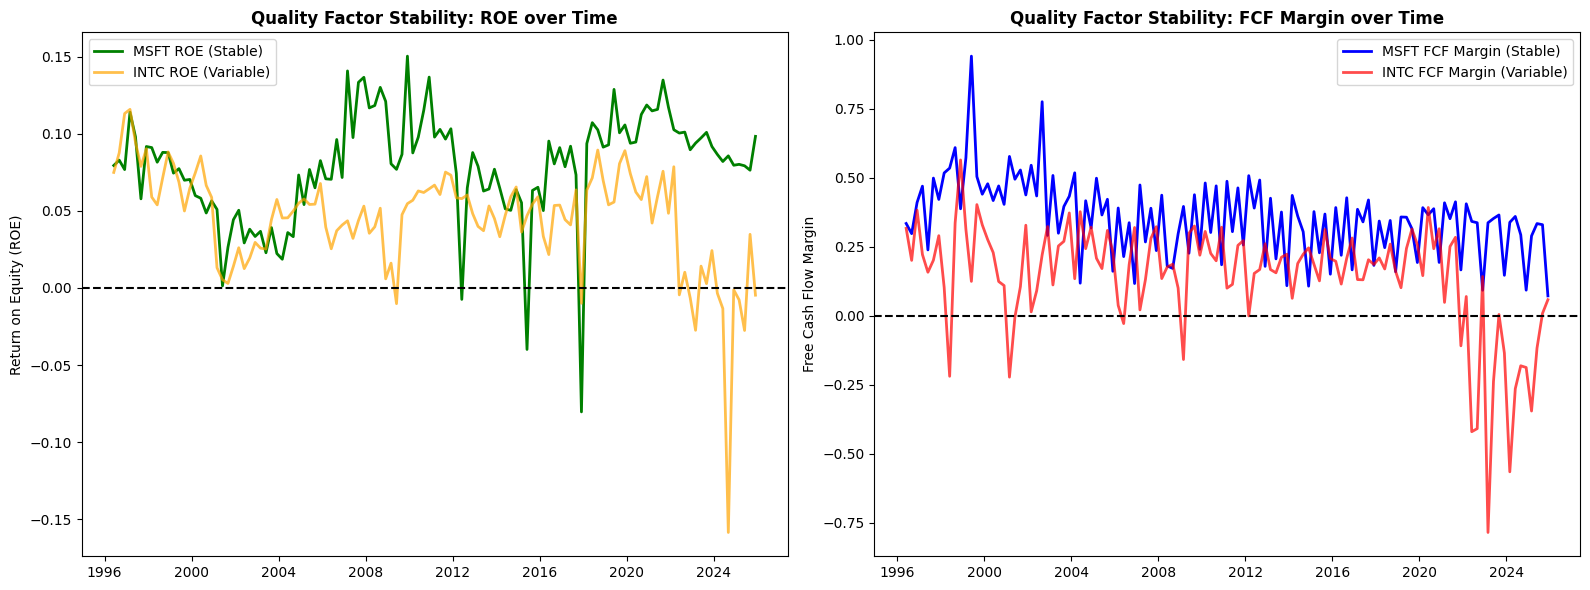

In [8]:
if os.path.exists('Thesis_Fundamentals.csv'):
    fund_df = pd.read_csv('Thesis_Fundamentals.csv', parse_dates=['Date'])

    # Calculate ROE and FCF Margin
    fund_df['ROE'] = fund_df['Net_Income'] / fund_df['Total_Equity']
    fund_df['FCF_Margin'] = (fund_df['Operating_CF'] + fund_df['CapEx']) / fund_df['Revenue']

    msft_data = fund_df[fund_df['Ticker'] == 'MSFT'].set_index('Date')
    msft_roe = msft_data['ROE']
    msft_fcf = msft_data['FCF_Margin']

    intc_data = fund_df[fund_df['Ticker'] == 'INTC'].set_index('Date')
    intc_roe = intc_data['ROE']
    intc_fcf = intc_data['FCF_Margin']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ROE
    axes[0].plot(msft_roe.index, msft_roe, label='MSFT ROE (Stable)', color='green', linewidth=2)
    axes[0].plot(intc_roe.index, intc_roe, label='INTC ROE (Variable)', color='orange', linewidth=2, alpha=0.7)
    axes[0].axhline(0, color='black', linestyle='--')
    axes[0].set_title('Quality Factor Stability: ROE over Time', fontweight='bold')
    axes[0].set_ylabel('Return on Equity (ROE)')
    axes[0].legend()

    # FCF Margin
    axes[1].plot(msft_fcf.index, msft_fcf, label='MSFT FCF Margin (Stable)', color='blue', linewidth=2)
    axes[1].plot(intc_fcf.index, intc_fcf, label='INTC FCF Margin (Variable)', color='red', linewidth=2, alpha=0.7)
    axes[1].axhline(0, color='black', linestyle='--')
    axes[1].set_title('Quality Factor Stability: FCF Margin over Time', fontweight='bold')
    axes[1].set_ylabel('Free Cash Flow Margin')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("\n 'Thesis_Fundamentals.csv' not found. Skipping Plot 9.6.")

## Market Regimes vs Daily Returns


Regime Difference Test
T-test (Low VIX vs High VIX Returns) p-value: 2.669513092966965e-07
Insight: Returns differ statistically across regimes (p < 0.05) → perfectly validates the use of the HMM.


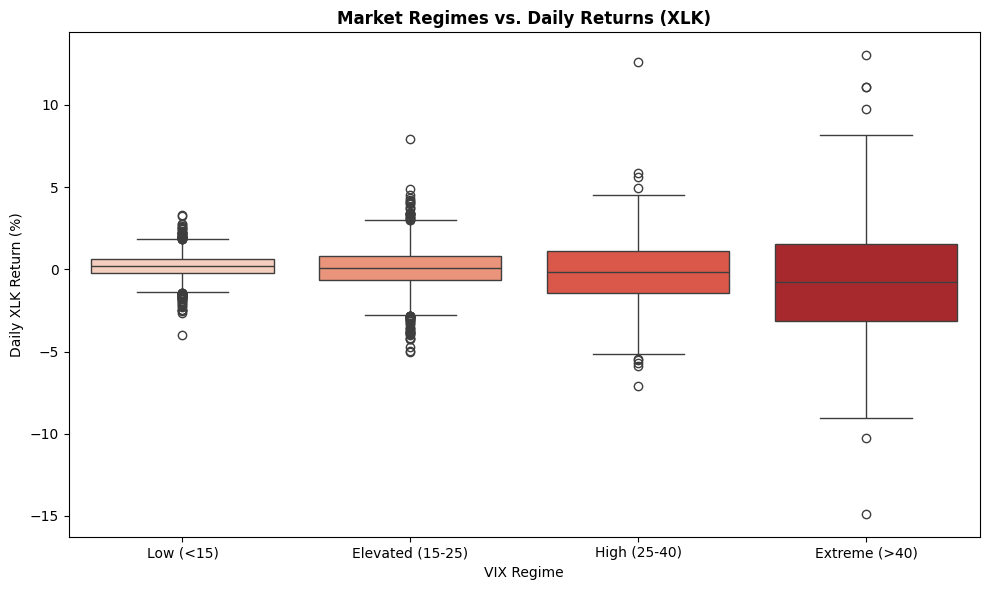

In [9]:
df_regime = pd.DataFrame({'XLK_Return': xlk_returns * 100, 'VIX': vix}).dropna()

print("\nRegime Difference Test")
# Validation for HMM
low_vix = df_regime[df_regime['VIX'] < 15]['XLK_Return']
high_vix = df_regime[df_regime['VIX'] > 25]['XLK_Return']

# Welch's t-test (equal_var=False) since variances likely differ across regimes
t_stat, p_val = stats.ttest_ind(low_vix, high_vix, equal_var=False)
print(f"T-test (Low VIX vs High VIX Returns) p-value: {p_val}")
if p_val < 0.05:
    print("Insight: Returns differ statistically across regimes (p < 0.05) → perfectly validates the use of the HMM.")

df_regime['VIX_Regime'] = pd.cut(df_regime['VIX'], bins=[0, 15, 25, 40, 100], labels=['Low (<15)', 'Elevated (15-25)', 'High (25-40)', 'Extreme (>40)'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='VIX_Regime', y='XLK_Return', data=df_regime, palette='Reds')
plt.title('Market Regimes vs. Daily Returns (XLK)', fontweight='bold')
plt.xlabel('VIX Regime')
plt.ylabel('Daily XLK Return (%)')
plt.tight_layout()
plt.show()


## Dispersion vs VIX

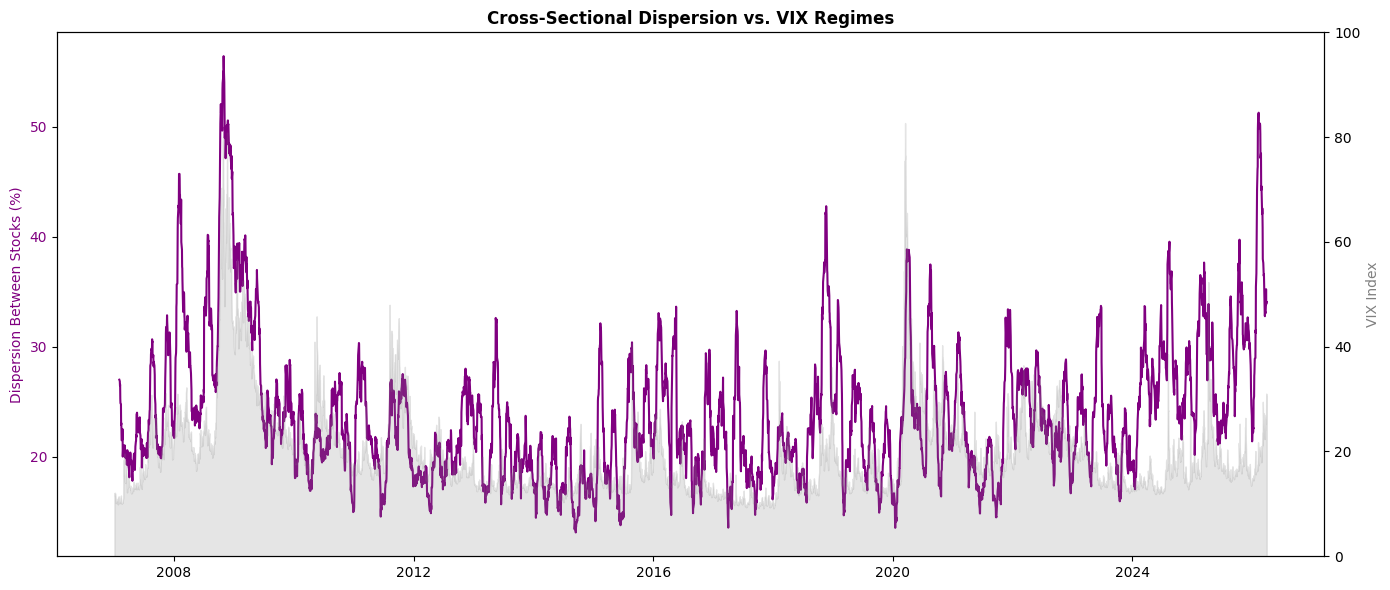

In [10]:
cs_dispersion = log_returns.std(axis=1) * np.sqrt(252) * 100
rolling_dispersion = cs_dispersion.rolling(21).mean()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(rolling_dispersion.index, rolling_dispersion, color='purple', label='Cross-Sectional Dispersion (Ann. %)')
ax1.set_ylabel('Dispersion Between Stocks (%)', color='purple')
ax1.tick_params(axis='y', labelcolor='purple')

ax2 = ax1.twinx()
ax2.fill_between(vix.index, vix, 0, color='gray', alpha=0.2, label='VIX Level')
ax2.set_ylabel('VIX Index', color='gray')
ax2.set_ylim(0, 100)

plt.title('Cross-Sectional Dispersion vs. VIX Regimes', fontweight='bold')
fig.tight_layout()
plt.show()